# **Data Analytics Project** #

##### Raw Dataset

| Column | Description |
| :--- | :--- |
| **Item_Identifier** | Product ID |
| **Item_Weight** | Weight of product |
| **Item_Fat_Content** | Content of product (`Low Fat` / `Regular`) |
| **Item_Visibility** | The percentage of all products in the store that are assigned to a specific product in the total display area |
| **Item_Type** | Category of product |
| **Item_MRP** | Maximum retail price of a product |
| **Outlet_Identifier** | Store ID |
| **Outlet_Establishment_Year** |  Year the store established |
| **Outlet_Size** | Size of the store |
| **Outlet_Location_Type** | The type of city where the store is located |
| **Outlet_Type** | Type of the store|
| **Item_Outlet_Sales** | Sales of product |

## **Setup and Configuration**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

## **Data Understanding**

### **Data Loading**

In [2]:
df = pd.read_csv('DA_raw.csv')

#### Initial Data Profiling

In [3]:
df.head(10)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


### **Data Quality Check &  Basic EDA**

##### Check Dataset Structure

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


##### Check Dataset Decsriptive Statistics

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Item_Weight,7060.0,12.857645,4.643456,4.555,8.773750,12.600000,16.850000,21.350000
Item_Visibility,8523.0,0.066132,0.051598,0.000,0.026989,0.053931,0.094585,0.328391
Item_MRP,8523.0,140.992782,62.275067,31.290,93.826500,143.012800,185.643700,266.888400
Outlet_Establishment_Year,8523.0,1997.831867,8.371760,1985.000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.290,834.247400,1794.331000,3101.296400,13086.964800


##### Check Missing Value

In [6]:
print('Ringkasan nilai null di DataFrame:')
df.isnull().sum()

Ringkasan nilai null di DataFrame:


Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [7]:
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

missing_data = pd.DataFrame({
    'Total Null': null_counts,
    'Persentase (%)': null_percentages
})
print(missing_data.sort_values(by='Persentase (%)', ascending=False))

                           Total Null  Persentase (%)
Outlet_Size                      2410       28.276428
Item_Weight                      1463       17.165317
Item_Identifier                     0        0.000000
Item_Fat_Content                    0        0.000000
Item_Visibility                     0        0.000000
Item_Type                           0        0.000000
Item_MRP                            0        0.000000
Outlet_Identifier                   0        0.000000
Outlet_Establishment_Year           0        0.000000
Outlet_Location_Type                0        0.000000
Outlet_Type                         0        0.000000
Item_Outlet_Sales                   0        0.000000


##### Check Zero Value

In [8]:
print((df['Item_Visibility'] == 0).sum())

526


##### Check Duplicate Value

In [9]:
duplicates = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicates}")

Jumlah data duplikat: 0


##### Check Consistency in Categorical Columns

In [10]:
categorical_cols = df.select_dtypes(include = 'object').columns.tolist()

for col in categorical_cols: 
    print(df[col].value_counts())

Item_Identifier
FDW13    10
FDG33    10
NCY18     9
FDD38     9
DRE49     9
         ..
FDY43     1
FDQ60     1
FDO33     1
DRF48     1
FDC23     1
Name: count, Length: 1559, dtype: int64
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
Outlet_Identifier
OUT027    935
OUT013    932
OUT049    930
OUT046    930
OUT035    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count, dt

##### Check Outlier in Numerical Columns

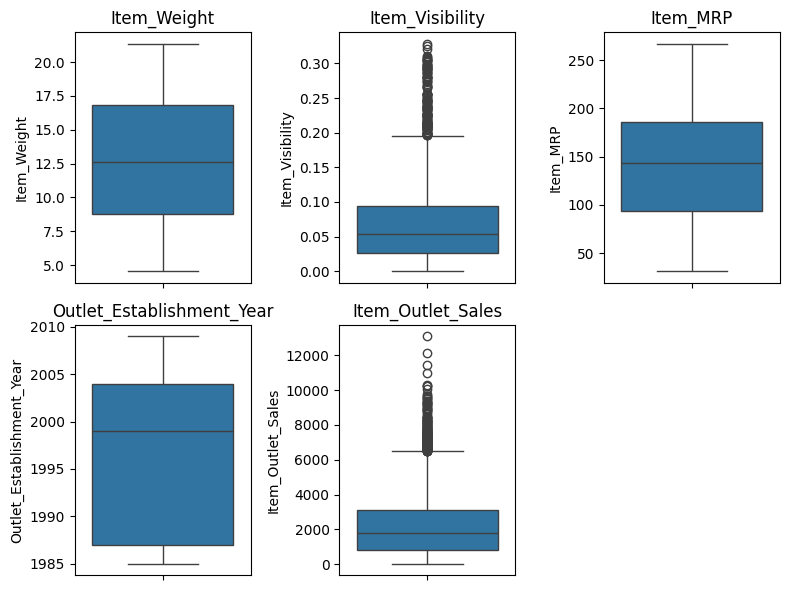

In [11]:
numerical_cols = df.select_dtypes(include =['int64', 'float64']).columns.tolist()

def check_univariate_num(df, numCols):
    n = len(numCols)
    rows = -(-n//3)
    plt.figure(figsize=(8,6))
    for i, col in enumerate(numCols, 1):
        plt.subplot(rows, 3, i)
        # contoh pake boxplot
        sns.boxplot(df[col])
        plt.title(col)
    plt.tight_layout()
    plt.show()
    
check_univariate_num(df, numerical_cols)

In [12]:
outlier_summary = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'Item_Weight': 0, 'Item_Visibility': 144, 'Item_MRP': 0, 'Outlet_Establishment_Year': 0, 'Item_Outlet_Sales': 186}


## **Data Preparation**

In [13]:
df_prep = df.copy()

### **Data Splitting**

### **Data Cleaning**

##### Handling Missing Values

In [14]:
df_prep['Item_Weight'] = df_prep['Item_Weight'].fillna(df_prep.groupby('Item_Identifier')['Item_Weight'].transform('mean'))
df_prep['Item_Weight'] = df_prep['Item_Weight'].fillna(df_prep.groupby('Item_Type')['Item_Weight'].transform('mean'))

In [15]:
df_prep['Item_Weight'].fillna(df_prep['Item_Weight'].mean(), inplace=True)

/var/folders/jr/4mwy7pj16md06q1j0mtcdr3m0000gn/T/ipykernel_54677/2681232698.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_prep['Item_Weight'].fillna(df_prep['Item_Weight'].mean(), inplace=True)


In [16]:
mode_outlet = df_prep.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=lambda x: x.mode().iloc[0])
df_prep.loc[df_prep['Outlet_Size'].isnull(), 'Outlet_Size'] = df_prep.loc[df['Outlet_Size'].isnull(), 'Outlet_Type'].apply(lambda x: mode_outlet[x])

##### Handling Zero Values

In [17]:
df_prep['Item_Visibility'] = df_prep['Item_Visibility'].replace(0, np.nan)
df_prep['Item_Visibility'] = df_prep['Item_Visibility'].fillna(df_prep.groupby('Item_Type')['Item_Visibility'].transform('mean'))

##### Handling Inconsistencies 

In [18]:
df_prep['Item_Fat_Content'] = df_prep['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

df_prep['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

##### Missing Value After Cleaning

In [19]:
print("Jumlah Missing Values setelah Cleaning:")
print(df_prep.isnull().sum())

Jumlah Missing Values setelah Cleaning:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


### **Data Transformation**

##### Feature Engineering

In [20]:
df_prep['Item_Category'] = df_prep['Item_Identifier'].apply(lambda x: x[:2])
df_prep['Item_Category'] = df_prep['Item_Category'].map({
    'FD': 'Food',
    'DR': 'Drinks',
    'NC': 'Non-Consumable'
})

In [21]:
# Handling Inconsistencies utk Item Category
df_prep.loc[df_prep['Item_Category'] == 'Non-Consumable', 'Item_Fat_Content'] = 'Non-Edible'

In [22]:
df_prep['Outlet_Years'] = 2013 - df_prep['Outlet_Establishment_Year'] # karena dataset diambil di tahun 2013

##### Check Feature Engineering 

In [23]:
print("\nLabel di Item_Category:")
print(df_prep['Item_Category'].unique())


Label di Item_Category:
['Food' 'Drinks' 'Non-Consumable']


In [24]:
print("Label di Item_Fat_Content:")
print(df_prep['Item_Fat_Content'].unique())

Label di Item_Fat_Content:
['Low Fat' 'Regular' 'Non-Edible']


In [25]:
df_prep[['Outlet_Years']].head()

,Outlet_Years
0,14
1,4
2,14
3,15
4,26


##### Export Excel

In [26]:
df_prep.to_csv('DA_clean.csv', index=False)

### **EDA After Cleaning**

##### Clean Dataset

| Column | Description |
| :--- | :--- |
| **Item_Identifier** | Product ID |
| **Item_Weight** | Weight of product |
| **Item_Fat_Content** | Content of product (`Low Fat` / `Regular` /`Non-Edible`) |
| **Item_Visibility** | The percentage of all products in the store that are assigned to a specific product in the total display area |
| **Item_Type** | Category of product |
| **Item_MRP** | Maximum retail price of a product |
| **Outlet_Identifier** | Store ID |
| **Outlet_Establishment_Year** |  Year the store established |
| **Outlet_Size** | Size of the store |
| **Outlet_Location_Type** | The type of city where the store is located |
| **Outlet_Type** | Type of the store|
| **Item_Outlet_Sales** | Sales of product |
| **Item_Category** | Product Category (`Food` / `Drinks`/ `Non-Consumable`)| 
| **Outlet_Years** | Outlet Age | 

##### Descriptive Statistics

In [27]:
df_prep.describe().T

,count,mean,std,min,25%,50%,75%,max
Item_Weight,8523.0,12.875418,4.645016,4.555000,8.785000,12.650000,16.850000,21.350000
Item_Visibility,8523.0,0.070485,0.048744,0.003575,0.033085,0.061883,0.094585,0.328391
Item_MRP,8523.0,140.992782,62.275067,31.290000,93.826500,143.012800,185.643700,266.888400
Outlet_Establishment_Year,8523.0,1997.831867,8.371760,1985.000000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.290000,834.247400,1794.331000,3101.296400,13086.964800
Outlet_Years,8523.0,15.168133,8.371760,4.000000,9.000000,14.000000,26.000000,28.000000


### **Encoding**

### **Scaling**

## **Modelling**

### **EDA After Modelling**

## **Evaluation**

## **Deployment**